# Model Training

In this notebook, we train a machine learning model to detect fraudulent transactions. 
<br> Baseline → Random Forest → XGBoost with class imbalance handling.

In [18]:
import pandas as pd
import numpy as np
import json, os, joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE

In [20]:
# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [21]:
with open('../data/processed/features.json') as f:
    FEATURES = json.load(f)

In [22]:
print('Data loaded.')
print(f'Train: {X_train.shape} | Fraud rate: {y_train.mean():.3%}')
print(f'Test:  {X_test.shape}  | Fraud rate: {y_test.mean():.3%}')

Data loaded.
Train: (1296675, 15) | Fraud rate: 0.579%
Test:  (555719, 15)  | Fraud rate: 0.386%


## Handle Class Imbalance with SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic fraud examples so the model learns better decision boundaries. <br>
If model is train on this as-is, the model gets lazy. It sees that 99.6% of examples are "not fraud" so it just learns to say "not fraud" every single time. It'll be 99.6% accurate and completely useless.

In [23]:
print('Before SMOTE:', y_train.value_counts().to_dict())

Before SMOTE: {0: 1289169, 1: 7506}


In [24]:
# Use sampling_strategy=0.1 (fraud becomes 10% of data — not 50%)
# Full 50/50 SMOTE on 500k rows is very slow
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [25]:
print('After SMOTE: ', pd.Series(y_res).value_counts().to_dict())
print(f'Resampled size: {X_res.shape}')

After SMOTE:  {0: 1289169, 1: 128916}
Resampled size: (1418085, 15)


## Helper: Evaluation Function

In [26]:
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

results = {}

Receive model
- Train it
- Get predictions (hard + probability)
- Calculate AUC-ROC and PR-AUC
- Draw confusion matrix + ROC curve
- Save model to disk
- Record scores for later comparison
- Return the trained model

In [27]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, save=True):
    # Train and predict
    model.fit(X_tr, y_tr) # model looks at all your training data and figures out the patterns.
    y_pred  = model.predict(X_te) # model uses what it learned to predict the labels for the test data.
    y_proba = model.predict_proba(X_te)[:, 1] # model gives the probability of each test sample being fraud (class 1)

    auc_roc = roc_auc_score(y_te, y_proba) # AUC-ROC measures how well the model can distinguish between fraud and legit transactions across all thresholds.
    pr_auc  = average_precision_score(y_te, y_proba) # PR-AUC measures the model's performance in terms of precision and recall across all thresholds.

    print(f'\n{'='*50}')
    print(f' {name}')
    print(f'{'='*50}')
    print(classification_report(y_te, y_pred, target_names=['Legit','Fraud']))
    print(f'AUC-ROC : {auc_roc:.4f}')
    print(f'PR-AUC  : {pr_auc:.4f}')

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred) # Confusion matrix 2x2 matrixshows the counts (true positives, true negatives, false positives, false negatives).
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1],
                                     name=name, color='tomato')
    axes[1].set_title('ROC Curve')
    plt.tight_layout()
    plt.savefig(f'../outputs/{name.lower().replace(" ","_")}_eval.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Save model
    if save:
        joblib.dump(model, f'../models/{name.lower().replace(" ","_")}.pkl')
        print(f'Model saved to models/{name.lower().replace(" ","_")}.pkl')

    # Store results (Recording results)
    results[name] = {
        'AUC-ROC': round(auc_roc, 4),
        'PR-AUC':  round(pr_auc, 4)
    }
    return model

# Models

## Logistic Regression (Baseline)

In [28]:
print("NaNs in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nNaNs in X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

NaNs in X_train:
Series([], dtype: int64)

NaNs in X_test:
Series([], dtype: int64)



 Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96    553574
       Fraud       0.04      0.73      0.07      2145

    accuracy                           0.93    555719
   macro avg       0.52      0.83      0.52    555719
weighted avg       1.00      0.93      0.96    555719

AUC-ROC : 0.9182
PR-AUC  : 0.1726


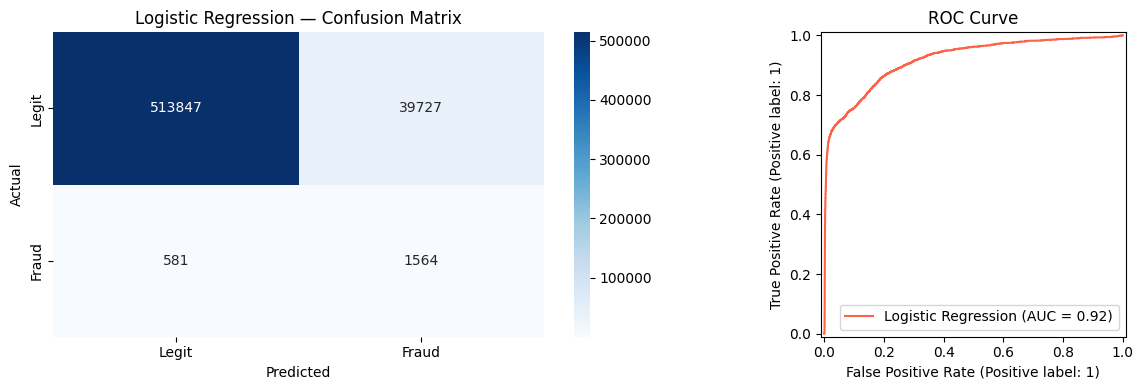

Model saved to models/logistic_regression.pkl


In [29]:
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr = evaluate_model('Logistic Regression', lr, X_res, y_res, X_test, y_test)

## Random Forest


 Random Forest
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    553574
       Fraud       0.20      0.83      0.33      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.91      0.66    555719
weighted avg       1.00      0.99      0.99    555719

AUC-ROC : 0.9900
PR-AUC  : 0.6324


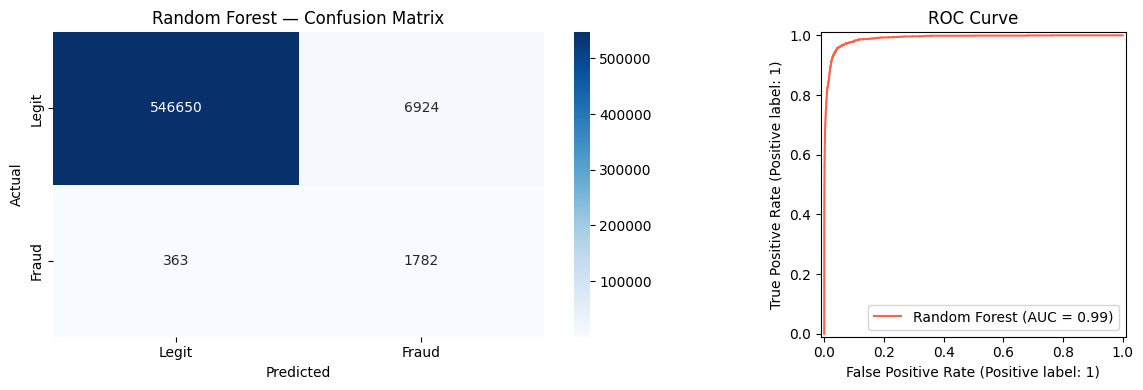

Model saved to models/random_forest.pkl


In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf = evaluate_model('Random Forest', rf, X_res, y_res, X_test, y_test)

## XGBoost (Best Performer)

In [31]:
# scale_pos_weight handles imbalance natively in XGBoost
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f'scale_pos_weight = {spw:.1f}')

scale_pos_weight = 171.8



 XGBoost
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00    553574
       Fraud       0.35      0.81      0.49      2145

    accuracy                           0.99    555719
   macro avg       0.68      0.90      0.74    555719
weighted avg       1.00      0.99      0.99    555719

AUC-ROC : 0.9923
PR-AUC  : 0.7189


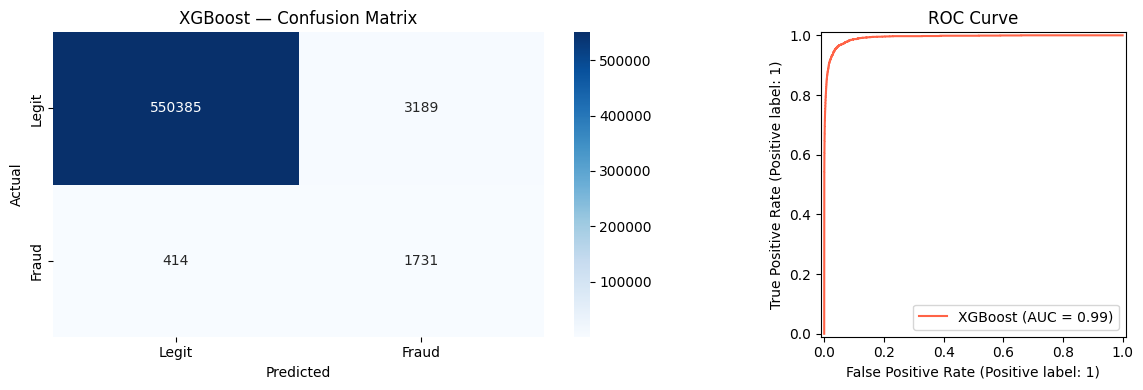

Model saved to models/xgboost.pkl


In [32]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb = evaluate_model('XGBoost', xgb, X_train, y_train, X_test, y_test)

## Model Comparison

In [33]:
summary = pd.DataFrame(results).T
print('\n=== Model Comparison ===')
print(summary)


=== Model Comparison ===
                     AUC-ROC  PR-AUC
Logistic Regression   0.9182  0.1726
Random Forest         0.9900  0.6324
XGBoost               0.9923  0.7189


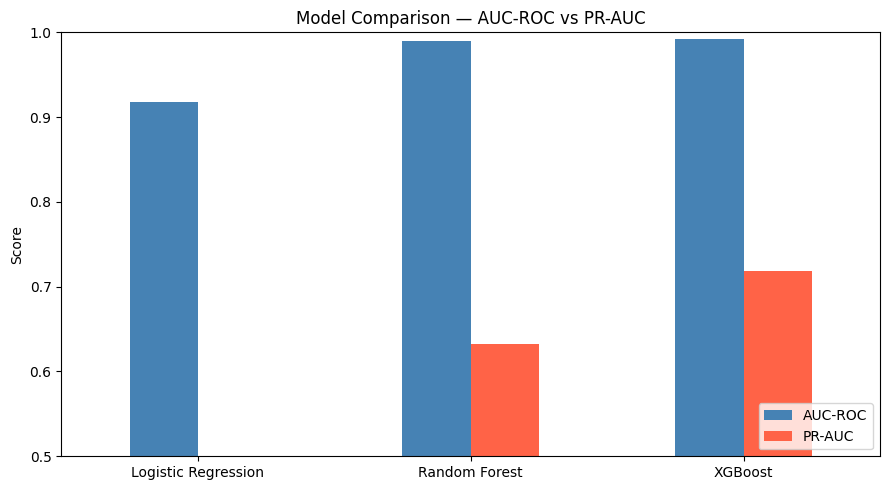

In [34]:
summary.plot(kind='bar', figsize=(9, 5), rot=0, color=['steelblue','tomato'])
plt.title('Model Comparison — AUC-ROC vs PR-AUC')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Evaluation Summary

#### Results at a Glance

| Model | Caught Fraud ✅ | Missed Fraud ❌ | False Alarms ⚠️ | AUC-ROC |
|---|---|---|---|---|
| Logistic Regression | 1,564 | 581 | 39,727 | 0.92 |
| Random Forest | 1,782 | 363 | 6,924 | 0.99 |
| **XGBoost** | **1,731** | **414** | **3,189** | **0.99** |

---

#### Reading the Confusion Matrix

Every prediction a model makes falls into one of four buckets:

| | Predicted Legit | Predicted Fraud |
|---|---|---|
| **Actual Legit** | ✅ True Negative — correctly safe | ❌ False Positive — wrongly flagged |
| **Actual Fraud** | ❌❌ False Negative — missed fraud | ✅ True Positive — caught fraud |

> **False Negatives are the costliest mistake** — real fraud slipping through undetected.  
> **False Positives are the noisiest mistake** — innocent customers getting blocked.

---

#### Why Not Just Use Accuracy?

The dataset has a **~0.5% fraud rate** — 99.5% of transactions are legitimate.

A model that predicts *"not fraud"* every single time would be **99.5% accurate** and completely useless. That's why we use:

- **AUC-ROC** → how well the model ranks fraud vs legit across all thresholds
- **PR-AUC** → more honest on imbalanced data; focuses specifically on fraud detection quality

---

#### The Core Tradeoff: Precision vs Recall

| Term | Question it answers | Winner |
|---|---|---|
| **Recall** | Of all actual frauds, how many did we catch? | Random Forest |
| **Precision** | Of everything flagged as fraud, how many were actually fraud? | XGBoost |

This tradeoff depends on what the business prioritises:

> 🏦 **Bank's priority** — catch every fraud, accept more false alarms → **Random Forest**  
> 👤 **Customer experience** — don't block legit transactions → **XGBoost**

---

#### Final Choice — XGBoost ✅

XGBoost is selected as the final model for three reasons:

1. **Half the false alarms** of Random Forest (3,189 vs 6,924) — significantly better customer experience
2. **Missed fraud difference is small** — only 51 more missed frauds than Random Forest, not worth double the false alarms
3. **Same AUC-ROC (0.99)** — identical overall discrimination ability

---

*Models trained on fraudTrain.csv · Evaluated on fraudTest.csv · 555,719 total transactions*

In [35]:
best = summary['PR-AUC'].idxmax()
print(f'\n Best model by PR-AUC: {best}')
print('→ Proceed to 05_explainability.ipynb')


 Best model by PR-AUC: XGBoost
→ Proceed to 05_explainability.ipynb
